In [ ]:
"""Importing Libraries"""

#General
import pandas as pd
import numpy as np
import scipy
import scipy.io
import os
import zipfile
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import random

#Deep Learning
import imgaug.augmenters as iaa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Input, Conv2D, Conv1D, MaxPooling1D, BatchNormalization, Dense, MaxPooling2D, Flatten, Dense, Dropout, concatenate, LSTM, Reshape, Concatenate, Activation, Permute, Multiply
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.svm import SVC

import gc

In [ ]:
"""Mounting Google Drive"""
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
import pickle

filename = "/content/drive/MyDrive/Meta Learning - New Project/Features_WG.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


eeg_data = loaded_data["Features_EEG_Reshaped"]
nirs_data = loaded_data["NIRS_All_Participants"]
labels = loaded_data["Labels_All_Participnats"]


filename = "/content/drive/MyDrive/Features_WG_NIRS.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


nirs_data = loaded_data["NIRS_All_Participants"]

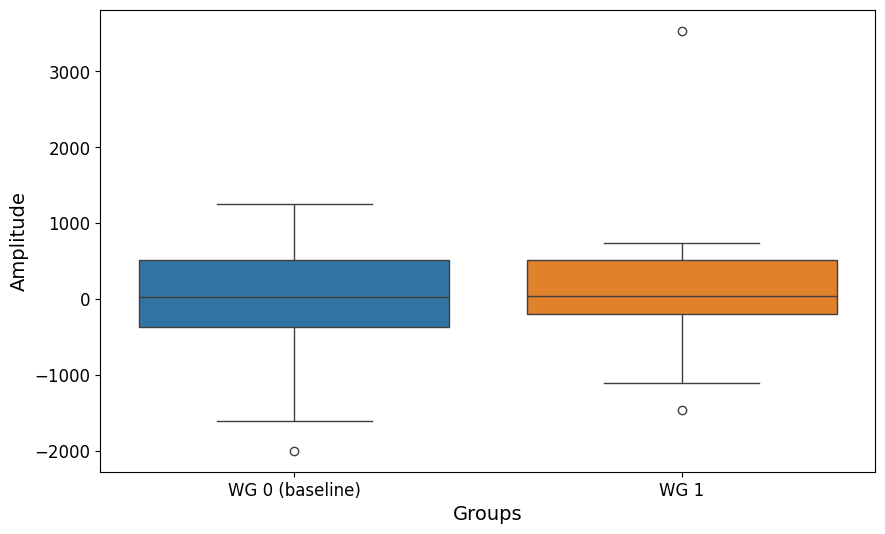

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming eeg_data is a numpy array of shape (2, 17, 360)
# eeg_data[0, :, 1] represents Left MI
# eeg_data[1, :, 1] represents Right MI

# Extract the data for Left MI and Right MI
left_mi_data = eeg_data[0, :, 1].reshape(-1)  # Flattening the 2D array to 1D
right_mi_data = eeg_data[1, :, 1].reshape(-1)  # Flattening the 2D array to 1D

# Creating a DataFrame for seaborn
import pandas as pd

data = {
    'WG 0 (baseline)': left_mi_data,
    'WG 1': right_mi_data
}

df = pd.DataFrame(data)

# Plotting the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xlabel('Groups', fontsize=14)  # Increasing font size for x-axis
plt.ylabel('Amplitude', fontsize=14)  # Increasing font size for y-axis
plt.xticks(fontsize=12)  # Adjusting font size for x-axis ticks
plt.yticks(fontsize=12)  # Adjusting font size for y-axis ticks
plt.ylabel('Amplitude')
plt.savefig('box_mfcc.eps', format='eps')
plt.show()

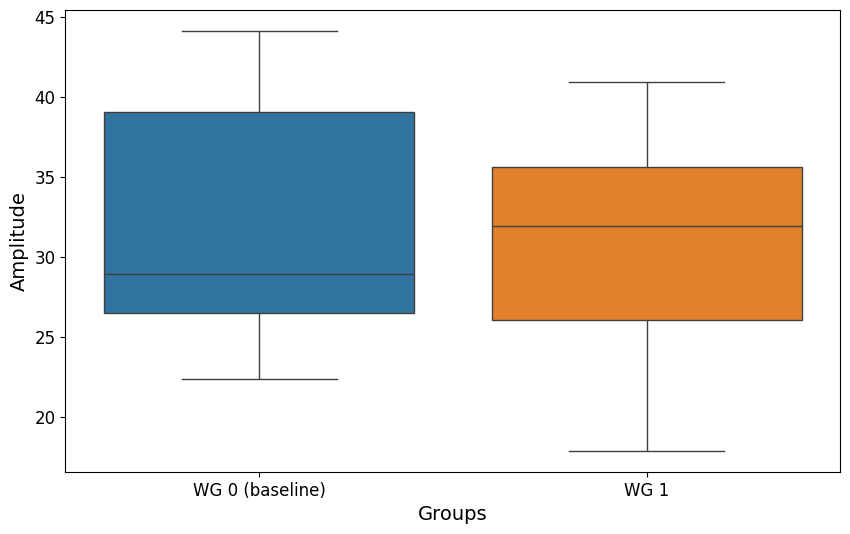

In [ ]:
import matplotlib.pyplot as plt

# Extract the data for Left MI and Right MI
left_mi_data = eeg_data[0, :, 0].reshape(-1)  # Flattening the 2D array to 1D
right_mi_data = eeg_data[1, :, 0].reshape(-1)  # Flattening the 2D array to 1D

# Creating a DataFrame for seaborn
import pandas as pd

data = {
    'WG 0 (baseline)': left_mi_data,
    'WG 1': right_mi_data
}

df = pd.DataFrame(data)

# Plotting the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xlabel('Groups', fontsize=14)  # Increasing font size for x-axis
plt.ylabel('Amplitude', fontsize=14)  # Increasing font size for y-axis
plt.xticks(fontsize=12)  # Adjusting font size for x-axis ticks
plt.yticks(fontsize=12)  # Adjusting font size for y-axis ticks
plt.ylabel('Amplitude')
plt.savefig('box_morlet.eps', format='eps')
plt.show()

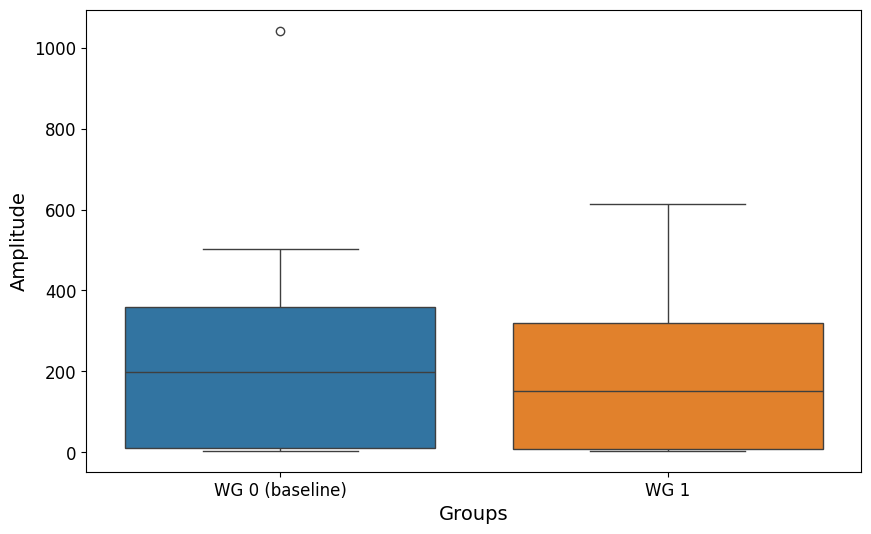

In [ ]:
import matplotlib.pyplot as plt

# Extract the data for Left MI and Right MI
left_mi_data = eeg_data[0, :, 6].reshape(-1)  # Flattening the 2D array to 1D
right_mi_data = eeg_data[1, :, 6].reshape(-1)  # Flattening the 2D array to 1D

# Creating a DataFrame for seaborn
import pandas as pd

data = {
    'WG 0 (baseline)': left_mi_data,
    'WG 1': right_mi_data
}

df = pd.DataFrame(data)

# Plotting the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xlabel('Groups', fontsize=14)  # Increasing font size for x-axis
plt.ylabel('Amplitude', fontsize=14)  # Increasing font size for y-axis
plt.xticks(fontsize=12)  # Adjusting font size for x-axis ticks
plt.yticks(fontsize=12)  # Adjusting font size for y-axis ticks
plt.ylabel('Amplitude')
plt.savefig('box_spectral_edge.eps', format='eps')
plt.show()

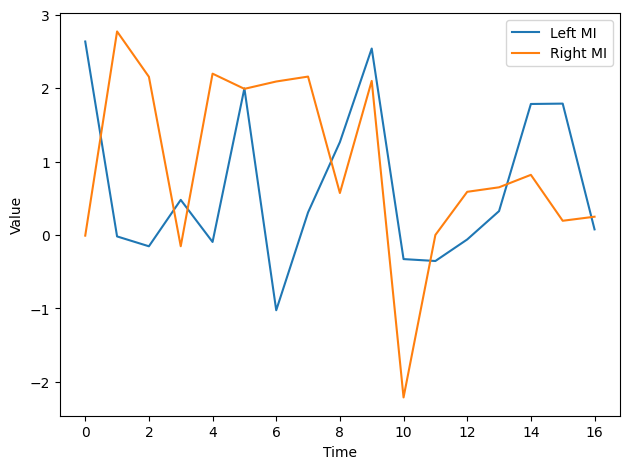

In [ ]:
import matplotlib.pyplot as plt

# Plot Features_EEG_Reshaped[0, :, 0]
plt.plot(eeg_data[0, :, 10], label='Left MI')

# Plot Features_EEG_Reshaped[1, :, 0]
plt.plot(eeg_data[1, :, 10], label='Right MI')

# Add labels and legend
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()

# Save the figure in EPS format
plt.savefig('TAFN_EM_DS2_MFCC.eps', format='eps')

# Show the plot
plt.show()


In [ ]:
eeg_data = eeg_data[0:150, :, :]
nirs_data = nirs_data[0:150, :, :]
labels = labels[0:150]

In [ ]:
def DataAugmentation(Data, Labels):
  # Define the augmentation pipeline
  augmentation = iaa.Sequential([
    iaa.Flipud(p=0.0005),                   # Flip images vertically
    iaa.Affine(rotate=(-0.1, 0.1)),       # Rotate images within the range -10 to 10 degrees
    iaa.AdditiveGaussianNoise(scale=(0, 0.005)),  # Add Gaussian noise
])

  # Create empty lists to store augmented features and labels
  augmented_features = []
  augmented_labels = []

  # Augment the data
  for i in range(len(Data)):
      feature = Data[i]
      label = Labels[i]

      # Apply augmentation to the feature
      augmented_feature = augmentation.augment_image(feature)

      # Add the augmented feature and corresponding label to the lists
      augmented_features.append(augmented_feature)
      augmented_labels.append(label)

      # Apply additional augmentation to generate more samples if needed
      for _ in range(50):  # Adjust the number of additional samples as desired
          augmented_feature = augmentation.augment_image(feature)
          augmented_features.append(augmented_feature)
          augmented_labels.append(label)

  # Convert the augmented features and labels lists to NumPy arrays
  augmented_features = np.array(augmented_features)
  augmented_labels = np.array(augmented_labels)

  # Check the shape of the augmented data
  print(augmented_features.shape)
  print(augmented_labels.shape)

  return augmented_features, augmented_labels

In [ ]:
EEG_augmented_features, augmented_labels = DataAugmentation(eeg_data, labels)
# EEG_augmented_features = (EEG_augmented_features - np.min(EEG_augmented_features)) / (np.max(EEG_augmented_features) - np.min(EEG_augmented_features))
EEG_augmented_features = EEG_augmented_features / np.max(EEG_augmented_features)

NIRS_augmented_features, augmented_labels = DataAugmentation(nirs_data, labels)
# NIRS_augmented_features = (NIRS_augmented_features - np.mean(NIRS_augmented_features)) / np.std(NIRS_augmented_features)
NIRS_augmented_features = NIRS_augmented_features / np.max(NIRS_augmented_features)

(7650, 17, 360)
(7650,)
(7650, 17, 792)
(7650,)


In [ ]:
nirs_data = NIRS_augmented_features
eeg_data = EEG_augmented_features
labels = augmented_labels

In [ ]:
np.shape(labels)

(7650,)

In [ ]:
onehot_encoder = OneHotEncoder(sparse=False)
labels = labels.reshape(len(labels), 1)
labels = onehot_encoder.fit_transform(labels)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
def generate_task_distribution(num_tasks, eeg_input_shape, nirs_input_shape):

    tasks = []

    for _ in range(num_tasks):
        # Randomly generate task parameters for EEG and NIRS parts
        eeg_task_params = np.random.randn(*eeg_input_shape)
        nirs_task_params = np.random.randn(*nirs_input_shape)

        # Store task parameters in a dictionary
        task = {"eeg_params": eeg_task_params, "nirs_params": nirs_task_params}
        tasks.append(task)

    return tasks

In [ ]:
from keras.layers import LSTM, Input, Dense, Concatenate, Flatten, Conv1D, BatchNormalization, Permute, Multiply, Activation, Add
from keras.models import Model
import tensorflow as tf

def tcn_layer(input_layer, num_filters=64, kernel_size=3, dilation_rate=1):
    conv = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal', activation='relu')(input_layer)
    conv = BatchNormalization()(conv)  # Adding batch normalization
    return conv

def temporal_attention(input_layer):
    x = Permute((2, 1))(input_layer)
    x = Dense(1, activation='tanh')(x)
    x = Permute((2, 1))(x)
    x = Multiply()([input_layer, x])
    x = Activation('softmax')(x)
    return x

def initialize_model(eeg_input_shape, nirs_input_shape, memory_slots=16, memory_slot_size=32):

    eeg_input = Input(shape=eeg_input_shape, name='eeg_input')
    eeg_tcn = tcn_layer(eeg_input)
    eeg_attention = temporal_attention(eeg_tcn)
    eeg_lstm = LSTM(64, return_sequences=True)(eeg_attention)
    eeg_flatten = Flatten()(eeg_lstm)

    nirs_input = Input(shape=nirs_input_shape, name='nirs_input')
    nirs_tcn = tcn_layer(nirs_input)
    nirs_attention = temporal_attention(nirs_tcn)
    nirs_lstm = LSTM(64, return_sequences=True)(nirs_attention)
    nirs_flatten = Flatten()(nirs_lstm)

    concatenated = Concatenate()([eeg_flatten, nirs_flatten])

    dense1 = Dense(64, activation='relu')(concatenated)
    dense2 = Dense(64, activation='relu')(dense1)

    output = Dense(2, activation='sigmoid')(dense2)

    model = Model(inputs=[eeg_input, nirs_input], outputs=output)


    return model

In [ ]:
def inner_loop(model, eeg_task_params, nirs_task_params, X_task, y_task, inner_optimizer, inner_steps=5):

    model.set_weights(initialized_model.get_weights())

    for _ in range(inner_steps):
        with tf.GradientTape() as tape:
            eeg_data_task, nirs_data_task = X_task

            # Forward pass
            y_pred = model([eeg_data_task, nirs_data_task])
            task_loss = tf.keras.losses.categorical_crossentropy(y_task, y_pred)

        gradients = tape.gradient(task_loss, model.trainable_variables)
        inner_optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return model

In [ ]:
def outer_loop(model, eeg_task_params, nirs_task_params, X_task, y_task, outer_optimizer):


    with tf.GradientTape() as tape:
        # Extract EEG and NIRS data from X_task
        eeg_data_task, nirs_data_task = X_task

        # Forward pass
        y_pred = model([eeg_data_task, nirs_data_task])
        task_loss = tf.keras.losses.categorical_crossentropy(y_task, y_pred)

    gradients = tape.gradient(task_loss, model.trainable_variables)
    outer_optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return model

In [ ]:
import numpy as np

def sample_task(task_distribution, episodic_memory=None, memory_strength=0.5):
    if episodic_memory is None:
        episodic_memory = []

    # Sampling from episodic memory with probability determined by memory_strength
    if np.random.rand() < memory_strength and len(episodic_memory) > 0:
        task = np.random.choice(episodic_memory)
    else:
        task = np.random.choice(task_distribution)

    # Append the current task to episodic memory
    episodic_memory.append(task)

    return task, episodic_memory

In [ ]:
num_tasks = 10
num_classes = 2  # 2 Classes for Dataset2
eeg_input_shape = np.shape(eeg_data)[1], np.shape(eeg_data)[2]

nirs_input_shape = np.shape(nirs_data)[1], np.shape(nirs_data)[2]

task_distribution = generate_task_distribution(num_tasks, eeg_input_shape, nirs_input_shape)

# Initialize the multi-input model
initialized_model = initialize_model(eeg_input_shape, nirs_input_shape)

# Set up optimizers
inner_optimizer = Adam(learning_rate=0.0001)
outer_optimizer = Adam(learning_rate=0.0001)

# Sample a task for training
task_params = sample_task(task_distribution)

In [ ]:
eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test = train_test_split(
      eeg_data, nirs_data, labels, test_size=0.2, random_state=42)

In [ ]:
X_task = [np.reshape(eeg_train, [np.shape(eeg_train)[0], np.shape(eeg_train)[1], np.shape(eeg_train)[2], 1]),
          np.reshape(nirs_train, [np.shape(nirs_train)[0], np.shape(nirs_train)[1], np.shape(nirs_train)[2], 1])]

y_task = labels_train

In [ ]:
episodic_memory = []

for meta_iteration in range(100):
    # Sample a task for training, considering episodic memory
    task_params, episodic_memory = sample_task(task_distribution, episodic_memory)

    # Inner loop: Train the model on the task's dataset
    model_inner = inner_loop(initialized_model, task_params["eeg_params"], task_params["nirs_params"], X_task, y_task, inner_optimizer)

    # Outer loop: Update the meta-parameters based on the computed gradients
    model_outer = outer_loop(model_inner, task_params["eeg_params"], task_params["nirs_params"], X_task, y_task, outer_optimizer)

    print(f"Meta-Iteration: {meta_iteration}")

Meta-Iteration: 0
Meta-Iteration: 1
Meta-Iteration: 2
Meta-Iteration: 3
Meta-Iteration: 4
Meta-Iteration: 5
Meta-Iteration: 6
Meta-Iteration: 7
Meta-Iteration: 8
Meta-Iteration: 9
Meta-Iteration: 10
Meta-Iteration: 11
Meta-Iteration: 12
Meta-Iteration: 13
Meta-Iteration: 14
Meta-Iteration: 15
Meta-Iteration: 16
Meta-Iteration: 17
Meta-Iteration: 18
Meta-Iteration: 19
Meta-Iteration: 20
Meta-Iteration: 21
Meta-Iteration: 22
Meta-Iteration: 23
Meta-Iteration: 24
Meta-Iteration: 25
Meta-Iteration: 26
Meta-Iteration: 27
Meta-Iteration: 28
Meta-Iteration: 29
Meta-Iteration: 30
Meta-Iteration: 31
Meta-Iteration: 32
Meta-Iteration: 33
Meta-Iteration: 34
Meta-Iteration: 35
Meta-Iteration: 36
Meta-Iteration: 37
Meta-Iteration: 38
Meta-Iteration: 39
Meta-Iteration: 40
Meta-Iteration: 41
Meta-Iteration: 42
Meta-Iteration: 43
Meta-Iteration: 44
Meta-Iteration: 45
Meta-Iteration: 46
Meta-Iteration: 47
Meta-Iteration: 48
Meta-Iteration: 49
Meta-Iteration: 50
Meta-Iteration: 51
Meta-Iteration: 52
Met

Meta-Iteration: 0, Test Loss: 0.044921766966581345, Test Accuracy: 0.9941176176071167
Meta-Iteration: 1, Test Loss: 0.04419573023915291, Test Accuracy: 0.9941176176071167
Meta-Iteration: 2, Test Loss: 0.043384332209825516, Test Accuracy: 0.9934640526771545
Meta-Iteration: 3, Test Loss: 0.042560797184705734, Test Accuracy: 0.9934640526771545
Meta-Iteration: 4, Test Loss: 0.04166353866457939, Test Accuracy: 0.9941176176071167
Meta-Iteration: 5, Test Loss: 0.04088563472032547, Test Accuracy: 0.9947712421417236
Meta-Iteration: 6, Test Loss: 0.040120966732501984, Test Accuracy: 0.9947712421417236
Meta-Iteration: 7, Test Loss: 0.03942033648490906, Test Accuracy: 0.9947712421417236
Meta-Iteration: 8, Test Loss: 0.03872903436422348, Test Accuracy: 0.9947712421417236
Meta-Iteration: 9, Test Loss: 0.03802378103137016, Test Accuracy: 0.9947712421417236
Meta-Iteration: 10, Test Loss: 0.03736955672502518, Test Accuracy: 0.9947712421417236
Meta-Iteration: 11, Test Loss: 0.036869220435619354, Test Ac

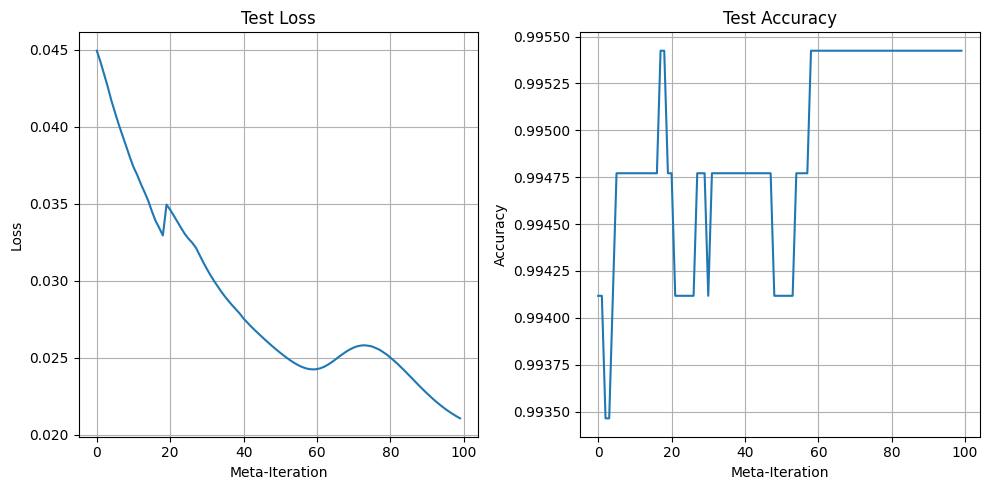

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store loss and accuracy values
losses = []
accuracies = []

# Compile the model
initialized_model.compile(optimizer=outer_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Iterate over meta-iterations
for meta_iteration in range(100):
    # Sample a task for training, considering episodic memory
    task_params, episodic_memory = sample_task(task_distribution, episodic_memory)

    # Inner loop: Train the model on the task's dataset
    model_inner = inner_loop(initialized_model, task_params["eeg_params"], task_params["nirs_params"], X_task, y_task, inner_optimizer)

    # Evaluate model on test data
    eeg_test_task = np.reshape(eeg_test, [np.shape(eeg_test)[0], np.shape(eeg_test)[1], np.shape(eeg_test)[2], 1])
    nirs_test_task = np.reshape(nirs_test, [np.shape(nirs_test)[0], np.shape(nirs_test)[1], np.shape(nirs_test)[2], 1])
    test_loss, test_accuracy = model_inner.evaluate([eeg_test_task, nirs_test_task], labels_test, verbose=0)

    # Outer loop: Update the meta-parameters based on the computed gradients
    model_outer = outer_loop(model_inner, task_params["eeg_params"], task_params["nirs_params"], X_task, y_task, outer_optimizer)

    print(f"Meta-Iteration: {meta_iteration}, Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

    # Append loss and accuracy to the lists
    losses.append(test_loss)
    accuracies.append(test_accuracy)

# Plot the loss and accuracy across meta-iterations
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Test Loss')
plt.xlabel('Meta-Iteration')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracies)
plt.title('Test Accuracy')
plt.xlabel('Meta-Iteration')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def Predictions_Scores(model, test_data, test_labels):
  predictions = model.predict(test_data)

  # Convert the predictions to class labels
  predicted_labels = np.argmax(predictions, axis=1)
  labels_test_updated = np.argmax(test_labels, axis=-1)

  cf_matrix = confusion_matrix(labels_test_updated, predicted_labels)
  plt.figure()
  ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')
  ax.set_title('Seaborn Confusion Matrix with labels\n\n');
  ax.set_xlabel('\nPredicted Values')
  ax.set_ylabel('Actual Values ')
  ## Display the visualization of the Confusion Matrix.
  plt.show()
  accuracy = accuracy_score(labels_test_updated, predicted_labels)
  precision = precision_score(labels_test_updated, predicted_labels, average='macro')
  recall = recall_score(labels_test_updated, predicted_labels, average='macro')
  f1 = f1_score(labels_test_updated, predicted_labels,average='macro')

  print('Accuracy: %.3f' % accuracy_score(labels_test_updated, predicted_labels))
  print('Precision: %.3f' % precision_score(labels_test_updated, predicted_labels, average='macro'))
  print('Recall: %.3f' % recall_score(labels_test_updated, predicted_labels, average='macro'))
  print('F1 Score: %.3f' % f1_score(labels_test_updated, predicted_labels,average='macro'))

  return accuracy, precision, recall, f1

48/48 [==============================] - 1s 5ms/step


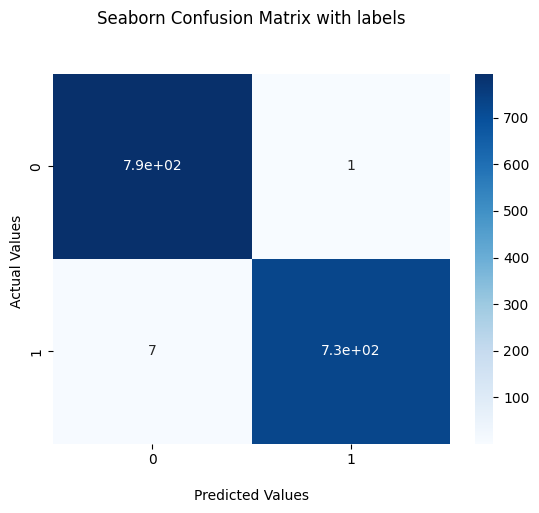

Accuracy: 0.995
Precision: 0.995
Recall: 0.995
F1 Score: 0.995


(0.9947712418300654,
 0.9949445908663553,
 0.9946091644204852,
 0.9947614938986812)

In [ ]:
X_test = [np.reshape(eeg_test, [np.shape(eeg_test)[0], np.shape(eeg_test)[1], np.shape(eeg_test)[2]]),
          np.reshape(nirs_test, [np.shape(nirs_test)[0], np.shape(nirs_test)[1], np.shape(nirs_test)[2]])]

y_test = labels_test

Predictions_Scores(model_outer, X_test, y_test)

In [ ]:
from sklearn.metrics import mean_squared_error


# Make predictions using the outter model
y_pred = model_outer.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(np.argmax(y_pred, axis = 1), np.argmax(y_test, axis = 1))

print(f"Mean Squared Error on New Data: {mse}")

48/48 [==============================] - 0s 5ms/step
Mean Squared Error on New Data: 0.00522875816993464
